In [12]:
import time
import numpy as np
import torch
from torchvision import datasets, transforms
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch.nn as nn
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader
from networks import LeNet
import matplotlib.pyplot as plt
from fvcore.nn import FlopCountAnalysis

In [13]:
# Hyperparameters
batch_size = 64
num_epochs = 20
learning_rate = 0.01

In [14]:
# Data transformations and loading MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=[0.1307], std=[0.3081])])
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform)

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

In [15]:
model = LeNet(channel=1, num_classes=10)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
scheduler = CosineAnnealingLR(optimizer, T_max=20)  # T_max = number of epochs

# Loss function
criterion = nn.CrossEntropyLoss()

Epoch [1/20], Train Loss: 0.2733, Val Loss: 0.0635, Time: 17.47 seconds
Epoch [2/20], Train Loss: 0.0653, Val Loss: 0.0554, Time: 16.88 seconds
Epoch [3/20], Train Loss: 0.0466, Val Loss: 0.0359, Time: 17.22 seconds
Epoch [4/20], Train Loss: 0.0370, Val Loss: 0.0333, Time: 17.02 seconds
Epoch [5/20], Train Loss: 0.0286, Val Loss: 0.0359, Time: 17.22 seconds
Epoch [6/20], Train Loss: 0.0226, Val Loss: 0.0288, Time: 17.12 seconds
Epoch [7/20], Train Loss: 0.0172, Val Loss: 0.0285, Time: 17.45 seconds
Epoch [8/20], Train Loss: 0.0141, Val Loss: 0.0331, Time: 17.58 seconds
Epoch [9/20], Train Loss: 0.0100, Val Loss: 0.0288, Time: 17.54 seconds
Epoch [10/20], Train Loss: 0.0081, Val Loss: 0.0291, Time: 17.65 seconds
Epoch [11/20], Train Loss: 0.0060, Val Loss: 0.0322, Time: 17.59 seconds
Epoch [12/20], Train Loss: 0.0041, Val Loss: 0.0292, Time: 17.77 seconds
Epoch [13/20], Train Loss: 0.0030, Val Loss: 0.0274, Time: 17.75 seconds
Epoch [14/20], Train Loss: 0.0022, Val Loss: 0.0298, Time: 1

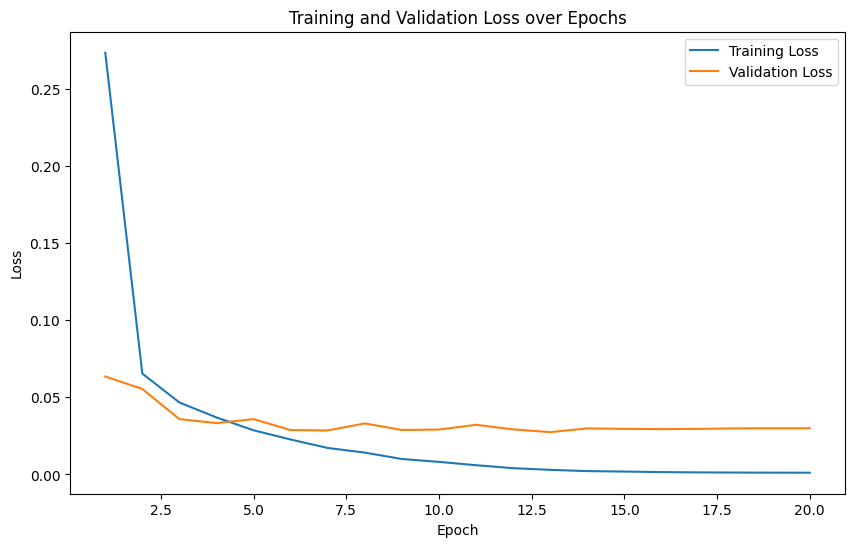

Unsupported operator aten::max_pool2d encountered 2 time(s)


Total FLOPs: 416520


In [16]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = model.to(device)
    model.train()

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        # Training
        model.train()
        start_time = time.time()
        total_train_loss = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        # Record average training loss for this epoch
        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                total_val_loss += loss.item()

        # Record average validation loss for this epoch
        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        # Update the learning rate
        scheduler.step()
        
        # Print epoch loss and time
        epoch_time = time.time() - start_time
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Time: {epoch_time:.2f} seconds')

    return train_losses, val_losses  # Return both training and validation losses for plotting

# Plot training and validation loss
def plot_loss(train_losses, val_losses):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_losses, label="Training Loss")
    plt.plot(epochs, val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss over Epochs")
    plt.legend()
    plt.show()

# Example usage:
# Assuming you have defined `train_loader`, `val_loader`, `model`, `criterion`, `optimizer`, and `scheduler`

num_epochs = 20  # Set your number of epochs
train_losses, val_losses = train_model(model, train_loader, test_loader, criterion, optimizer, scheduler, num_epochs)

plot_loss(train_losses, val_losses)

sample_input = torch.randn(1, 1, 28, 28).to(device)  # MNIST image size
flops = FlopCountAnalysis(model, sample_input)
print(f"Total FLOPs: {flops.total()}")